<div style="
    background-color:#E23744;
    padding:0px;
    border-radius:18px;
    text-align:center;
">

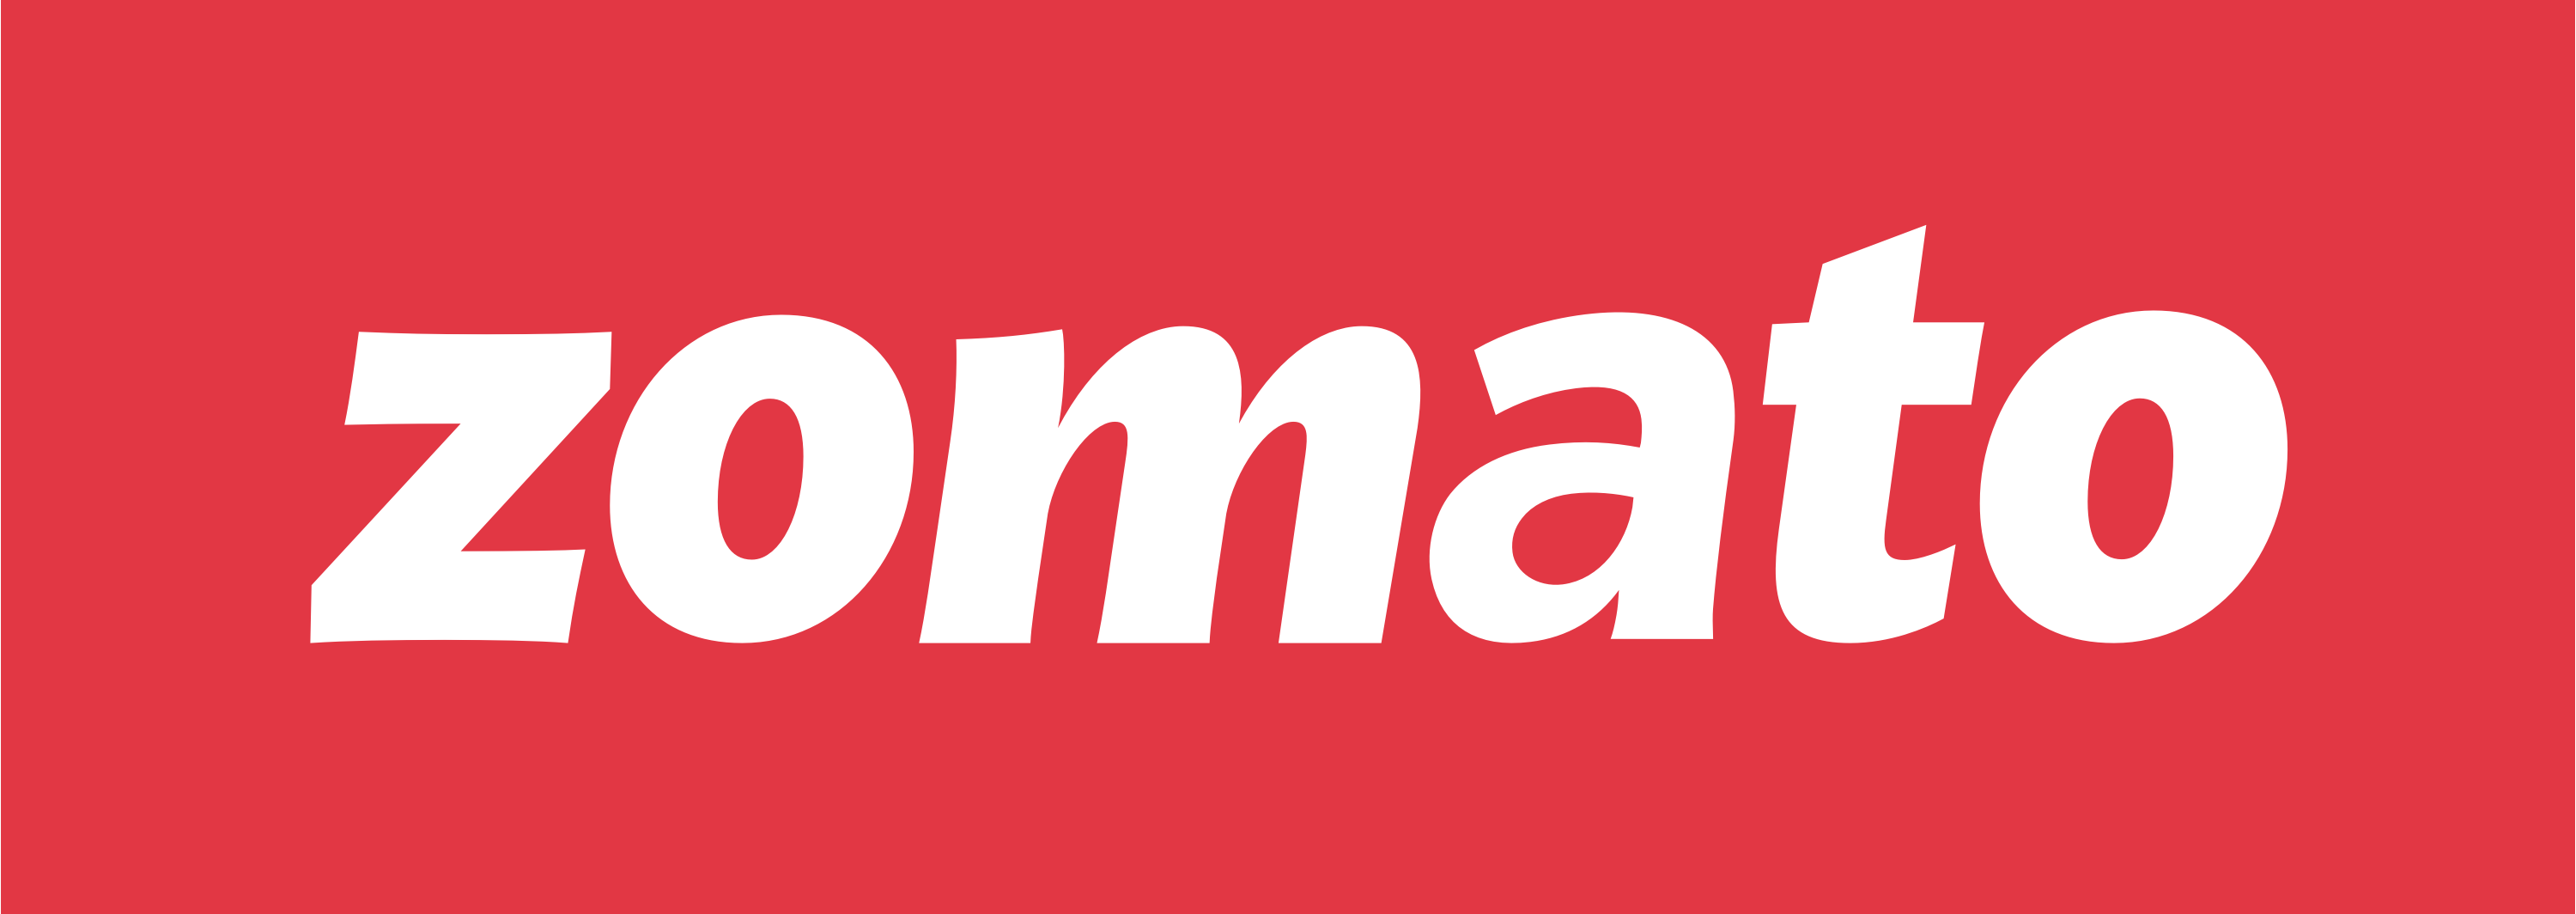

</div>

<div style="
    background-color:#E23744;
    padding:30px;
    border-radius:18px;
    text-align:center;
">

<h1 style="
    color:white;
    font-size:32px;
    font-weight:700;
    margin:0;
    line-height:1.3;
    text-align:center;
">
    Analysis of Zomato's Food Delivery Operations
</h1>

<p style="
    color:white;
    font-size:20px;
    font-weight:500;
    margin:10px 0 0;
    line-height:1.5;
    text-align:center;
    width:100%;
">
    Exploring the Key Factors Influencing Food Delivery Time
</p>

</div>

## Project Description

This project focuses on analyzing Zomato's food delivery operations and understanding the factors associated with delivery time. The dataset contains information related to delivery personnel, restaurants, delivery locations, weather conditions, road traffic, vehicle conditions, order types, festivals, distance, and delivery duration.

The analysis aims to explore the food delivery process and identify how different operational and environmental factors are related to delivery time. Python will be used to examine the dataset and derive meaningful insights from the available information.

## Project Objectives

**The key objectives of this project are:**

- To analyze the overall **delivery time** of food orders.
- To examine the relationship between **road traffic conditions** and delivery time.
- To study how **weather conditions** are associated with delivery time.
- To analyze delivery time across different **types of orders**.
- To examine the relationship between **delivery distance** and delivery time.
- To explore how **delivery locations** are associated with variations in delivery time.
- To identify the key factors that are most closely associated with food delivery time.

## Dataset Overview

The dataset contains 22 columns covering order details, delivery personnel, locations, environmental conditions, vehicle information, and delivery performance.

| Column | Description |
|---|---|
| `ID` | Unique identifier for each order. |
| `Delivery_person_ID` | Identifier of the delivery person. |
| `Delivery_person_Age` | Age of the delivery person. |
| `Delivery_person_Ratings` | Rating received by the delivery person. |
| `Restaurant_latitude` | Latitude of the restaurant location. |
| `Restaurant_longitude` | Longitude of the restaurant location. |
| `Delivery_location_latitude` | Latitude of the delivery location. |
| `Delivery_location_longitude` | Longitude of the delivery location. |
| `Order_Date` | Date on which the order was placed. |
| `Time_Orderd` | Time at which the order was placed. |
| `Time_Order_picked` | Time at which the order was picked up. |
| `Weather_conditions` | Weather condition during the delivery. |
| `Road_traffic_density` | Traffic condition during the delivery. |
| `Vehicle_condition` | Condition of the delivery vehicle. |
| `Type_of_order` | Category of the food order. |
| `Type_of_vehicle` | Type of vehicle used for delivery. |
| `multiple_deliveries` | Number of deliveries handled together. |
| `Festival` | Indicates whether the order was placed during a festival period. |
| `City` | Classification of the delivery location. |
| `Time_taken (min)` | Total time taken to complete the delivery, in minutes. |
| `distance_km` | Distance between the restaurant and delivery location, in kilometres. |
| `delivery_speed` | Categorised delivery speed based on delivery time. |

<div style="
    background-color:#E23744;
    padding:18px;
    border-radius:18px;
    text-align:center;
">

<h2 style="
    color:white;
    font-size:24px;
    font-weight:700;
    margin:0;
    line-height:1.3;
    text-align:center;
">
    Importing Libraries and Warnings
</h2>

</div>

### Import Libraries

The required Python libraries are imported for data manipulation and numerical analysis.

In [2]:
import pandas as pd
import numpy as np

### Import Warnings

The warnings module is imported to manage unnecessary warning messages during the analysis.

In [3]:
import warnings
warnings.filterwarnings('ignore')

<div style="
    background-color:#E23744;
    padding:18px;
    border-radius:18px;
    text-align:center;
">

<h2 style="
    color:white;
    font-size:24px;
    font-weight:700;
    margin:0;
    line-height:1.3;
    text-align:center;
">
    Data Loading and Review
</h2>

</div>

### Load the Dataset

The Zomato food delivery dataset is loaded into a Pandas DataFrame for initial review and further analysis.

In [4]:
df = pd.read_csv("zomato_cleaned.csv")

### Initial Dataset Inspection

The dataset is examined to understand its size, structure, data types, and basic statistical characteristics before proceeding with data preprocessing.

In [5]:
df.shape

# Shows the number of rows and columns.

(38964, 22)

In [6]:
df.columns

# Displays all column names

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)',
       'distance_km', 'delivery_speed'],
      dtype='object')

In [7]:
df.info()

# Shows column names, data types, and non-null counts.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38964 entries, 0 to 38963
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           38964 non-null  object 
 1   Delivery_person_ID           38964 non-null  object 
 2   Delivery_person_Age          37945 non-null  float64
 3   Delivery_person_Ratings      37909 non-null  float64
 4   Restaurant_latitude          38964 non-null  float64
 5   Restaurant_longitude         38964 non-null  float64
 6   Delivery_location_latitude   38964 non-null  float64
 7   Delivery_location_longitude  38964 non-null  float64
 8   Order_Date                   38964 non-null  object 
 9   Time_Orderd                  38129 non-null  object 
 10  Time_Order_picked            38964 non-null  object 
 11  Weather_conditions           38964 non-null  object 
 12  Road_traffic_density         38964 non-null  object 
 13  Vehicle_conditio

In [8]:
df.describe()

# Provides basic statistics for numerical columns.

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken (min),distance_km
count,37945.000000,37909.000000,38964.000000,38964.000000,38964.000000,38964.000000,38964.000000,38964.000000,38964.000000,38964.000000
mean,29.607089,4.631879,18.915583,76.914536,18.979545,76.978498,0.995534,0.749589,26.581511,9.765092
std,5.763202,0.317006,5.460635,3.498179,5.462504,3.498357,0.817312,0.572172,9.339546,5.605705
min,20.000000,2.500000,9.957144,72.768726,9.967144,72.778726,0.000000,0.000000,10.000000,1.465067
25%,25.000000,4.500000,12.986047,73.897902,13.066047,73.938972,0.000000,0.000000,19.000000,4.658009
50%,30.000000,4.700000,19.065838,76.618203,19.124049,76.663067,1.000000,1.000000,26.000000,9.219906
75%,35.000000,4.900000,22.751234,78.368855,22.820072,78.405467,2.000000,1.000000,33.000000,13.681590
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,2.000000,3.000000,54.000000,20.969489


In [9]:
df.head()

# Displays the first five rows of the dataset.

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),distance_km,delivery_speed
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,...,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,10.280582,Slow
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,...,High,1,Meal,motorcycle,1.0,No,Metropolitian,23,6.242319,Average
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,...,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21,13.787860,Average
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,...,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20,2.930258,Average
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,...,Jam,1,Snack,scooter,1.0,No,Metropolitian,41,19.396618,Slow


In [10]:
df.tail()

# Displays the last five rows of the dataset.

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),distance_km,delivery_speed
38959,0x1178,RANCHIRES16DEL01,35.0,4.2,23.371292,85.327872,23.481292,85.437872,08-03-2022,21:45,...,Jam,2,Drinks,motorcycle,1.0,No,Metropolitian,33,16.600272,Average
38960,0x7c09,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35,...,High,1,Meal,motorcycle,0.0,No,Metropolitian,32,1.489846,Average
38961,0x4f8d,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50,...,Low,1,Drinks,scooter,0.0,No,Metropolitian,16,4.657195,Fast
38962,0x5eee,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35,...,High,0,Snack,motorcycle,1.0,No,Metropolitian,26,6.232393,Average
38963,0x5fb2,RANCHIRES09DEL02,23.0,4.9,23.351058,85.325731,23.431058,85.405731,02-03-2022,17:10,...,Medium,2,Snack,scooter,1.0,No,Metropolitian,36,12.074396,Slow


<div style="
    background-color:#E23744;
    padding:18px;
    border-radius:18px;
    text-align:center;
">

<h2 style="
    color:white;
    font-size:24px;
    font-weight:700;
    margin:0;
    line-height:1.3;
    text-align:center;
">
    Data Cleaning & Preprocessing
</h2>

</div>

####  **I. Check missing values**

Missing values are checked to assess the completeness of the dataset.

In [11]:
df.isnull().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1019
Delivery_person_Ratings        1055
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                     835
Time_Order_picked                 0
Weather_conditions                0
Road_traffic_density              0
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries               0
Festival                          0
City                              0
Time_taken (min)                  0
distance_km                       0
delivery_speed                    0
dtype: int64

> **Finding:** Missing values are present in `Delivery_person_Age`, `Delivery_person_Ratings`, and `Time_Orderd`.

In [12]:
df.drop(columns=['Delivery_person_Age'], inplace=True)

> **Finding:** `Delivery_person_Age` was removed because it is not directly relevant to the defined project objectives.

In [13]:
df.drop(columns=['Delivery_person_Ratings'], inplace=True)

> **Finding:** `Delivery_person_Ratings` was removed as it is not required for the defined analysis objectives.

In [16]:
df['Time_Orderd'].value_counts(dropna=False).head(20)

Time_Orderd
NaN            835
17:55          407
21:55          402
19:50          401
21:15          399
18:35          396
19:55          394
0.833333333    388
21:35          385
22:20          384
21:20          384
17:40          383
22:45          381
18:10          381
22:10          377
20:40          376
20:50          376
21:40          376
20:35          375
17:35          375
Name: count, dtype: int64

> **Finding:** `Time_Orderd` contains 835 missing values and inconsistent time representations, including standard time formats and decimal values. The column requires standardization before missing values are handled.

#### **II. Check duplicate records**

Duplicate records are checked to ensure that the same order has not been recorded more than once.

In [17]:
df.duplicated().sum()

np.int64(0)

> **Finding:** No duplicate records were found in the dataset.

#### **III. Check inconsistent categorical values**

Categorical columns are examined for inconsistent values that may affect the accuracy of the analysis.

In [19]:
categorical_columns = [
    'Weather_conditions',
    'Road_traffic_density',
    'Type_of_order',
    'Type_of_vehicle',
    'Festival',
    'City'
]

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].dropna().unique())


Weather_conditions:
['Fog' 'Stormy' 'Sandstorms' 'Windy' 'Cloudy' 'Sunny']

Road_traffic_density:
['Jam' 'High' 'Medium' 'Low']

Type_of_order:
['Snack' 'Meal' 'Drinks' 'Buffet']

Type_of_vehicle:
['motorcycle' 'scooter' 'electric_scooter']

Festival:
['No' 'Yes']

City:
['Metropolitian' 'Urban' 'Semi-Urban']


##### **Object to datetime**

>The `Order_Date`, `Time_Orderd` and `Time_Order_picked` column is checked and converted from text format to datetime format for accurate date-based analysis.

In [20]:
df[['Order_Date', 'Time_Orderd', 'Time_Order_picked']].dtypes

Order_Date           object
Time_Orderd          object
Time_Order_picked    object
dtype: object

In [96]:
df['Order_Date'] = pd.to_datetime(
    df['Order_Date'],
    format='%d-%m-%Y',
    errors='coerce'
)

In [97]:
df['Order_Date'].isnull().sum(), df['Order_Date'].dtype

(np.int64(0), dtype('<M8[ns]'))

##### **Inconsistency in `Time_Orderd`**
>The `Time_Orderd` column is inspected and standardized to ensure that different time representations are converted into a consistent format.

In [23]:
df['Time_Orderd'].dropna().apply(type).value_counts()

Time_Orderd
<class 'str'>    38129
Name: count, dtype: int64

In [40]:
df['Time_Orderd'].dropna().unique()

array(['21:55', '14:55', '17:30', '09:20', '19:50', '20:25', '20:30',
       '21:15', '20:20', '22:30', '08:15', '19:30', '12:25', '18:35',
       '20:35', '23:20', '21:20', '23:35', '22:35', '23:25', '13:35',
       '18:55', '14:15', '0.458333333', '09:45', '08:40', '0.958333333',
       '17:25', '19:45', '19:10', '10:55', '21:40', '0.791666667',
       '16:45', '11:30', '15:10', '22:45', '20:45', '22:50', '17:55',
       '22:25', '22:40', '23:50', '15:25', '10:20', '20:55', '20:10',
       '12:10', '15:30', '20:50', '12:35', '0.875', '18:15', '18:20',
       '11:45', '12:45', '23:30', '10:50', '21:25', '10:10', '17:50',
       '22:20', '23:40', '12:40', '23:55', '10:25', '08:45', '10:35',
       '23:45', '19:55', '22:15', '23:10', '18:25', '22:10', '18:45',
       '16:50', '1', '21:10', '14:20', '10:15', '08:50', '0.375', '17:45',
       '08:30', '21:45', '14:50', '18:10', '12:30', '17:10', '19:15',
       '20:40', '17:20', '18:30', '21:35', '13:10', '19:35', '09:50',
       '0.83333

> **Finding:** `Time_Orderd` contains both standard time values and decimal representations of time. These values need to be standardized before converting the column to a proper time format.

In [41]:
def convert_time(value):
    if pd.isna(value):
        return value
    
    value = str(value).strip()
    
    if ':' in value:
        return value
    
    decimal_time = float(value)
    
    if decimal_time == 1:
        return '00:00'
    
    total_minutes = round(decimal_time * 24 * 60)
    hours = (total_minutes // 60) % 24
    minutes = total_minutes % 60
    
    return f'{hours:02d}:{minutes:02d}'

df['Time_Orderd'] = df['Time_Orderd'].apply(convert_time)

**Note:**
* Some time values are stored as decimal fractions of a 24-hour day (e.g., 0.5 represents 12:00 and 0.75 represents 18:00).
* This function converts these decimal values into HH:MM format, while retaining existing HH:MM values and leaving missing values unchanged.

In [42]:
df['Time_Orderd'].dropna().unique()

array(['21:55', '14:55', '17:30', '09:20', '19:50', '20:25', '20:30',
       '21:15', '20:20', '22:30', '08:15', '19:30', '12:25', '18:35',
       '20:35', '23:20', '21:20', '23:35', '22:35', '23:25', '13:35',
       '18:55', '14:15', '11:00', '09:45', '08:40', '23:00', '17:25',
       '19:45', '19:10', '10:55', '21:40', '19:00', '16:45', '11:30',
       '15:10', '22:45', '20:45', '22:50', '17:55', '22:25', '22:40',
       '23:50', '15:25', '10:20', '20:55', '20:10', '12:10', '15:30',
       '20:50', '12:35', '21:00', '18:15', '18:20', '11:45', '12:45',
       '23:30', '10:50', '21:25', '10:10', '17:50', '22:20', '23:40',
       '12:40', '23:55', '10:25', '08:45', '10:35', '23:45', '19:55',
       '22:15', '23:10', '18:25', '22:10', '18:45', '16:50', '00:00',
       '21:10', '14:20', '10:15', '08:50', '09:00', '17:45', '08:30',
       '21:45', '14:50', '18:10', '12:30', '17:10', '19:15', '20:40',
       '17:20', '18:30', '21:35', '13:10', '19:35', '09:50', '20:00',
       '12:50', '10:

> **Finding:** The different time representations in `Time_Orderd` have been standardized into a consistent `HH:MM` format.

In [43]:
df['Time_Orderd'] = pd.to_datetime(
    df['Time_Orderd'],
    format='%H:%M',
    errors='coerce'
)

In [44]:
df['Time_Orderd'].dtype

dtype('<M8[ns]')

> **Finding:** `Time_Orderd` was successfully converted to datetime format after standardizing the inconsistent time representations.

In [68]:
df['Time_Order_picked'].dropna().unique()

array(['22:10', '15:05', '17:40', '09:30', '20:05', '20:35', '15:10',
       '20:40', '21:30', '20:25', '22:45', '08:30', '19:45', '12:30',
       '18:50', '23:30', '21:35', '23:45', '22:50', '22:40', '23:35',
       '13:40', '19:10', '14:25', '11:10', '09:55', '08:55', '23:10',
       '17:30', '18:35', '19:50', '19:25', '0.458333333', '21:45',
       '19:15', '16:55', '11:40', '15:15', '22:55', '20:55', '23:05',
       '0.75', '0.958333333', '22:35', '0.916666667', '23:55', '15:40',
       '10:30', '0.875', '20:15', '12:15', '15:45', '24:05:00', '12:45',
       '21:15', '18:20', '18:25', '11:50', '12:50', '10:55', '21:40',
       '10:20', '17:55', '22:25', '23:50', '12:55', '24:10:00', '10:40',
       '0.375', '20:20', '20:45', '10:50', '0.833333333', '23:15',
       '22:20', '21:05', '0.708333333', '24:15:00', '21:20', '14:35',
       '10:25', '09:05', '08:40', '20:50', '23:40', '21:50', '0.625',
       '17:20', '19:30', '17:25', '20:10', '17:35', '1', '0.791666667',
       '19:05', 

In [69]:
def standardize_time(value):
    if pd.isna(value):
        return value

    value = str(value).strip()

    # Handle HH:MM:SS format
    if value.count(':') == 2:
        hours, minutes, seconds = value.split(':')
        hours = int(hours)
        minutes = int(minutes)

        # Convert 24:xx to 00:xx
        if hours == 24:
            hours = 0

        return f'{hours:02d}:{minutes:02d}'

    # Handle HH:MM format
    if ':' in value:
        hours, minutes = value.split(':')
        return f'{int(hours):02d}:{int(minutes):02d}'

    # Handle decimal representation of time
    decimal_time = float(value)

    if decimal_time == 1:
        return '00:00'

    total_minutes = round(decimal_time * 24 * 60)
    hours = (total_minutes // 60) % 24
    minutes = total_minutes % 60

    return f'{hours:02d}:{minutes:02d}'

**Note:**
* The time columns contain values in different formats, including HH:MM, HH:MM:SS, decimal fractions of a 24-hour day, and 24:xx time values.
* This function standardizes these different representations into a consistent HH:MM format before converting the column to datetime.

In [71]:
df['Time_Order_picked'] = df['Time_Order_picked'].apply(standardize_time)

In [72]:
df['Time_Order_picked'].dropna().unique()

array(['22:10', '15:05', '17:40', '09:30', '20:05', '20:35', '15:10',
       '20:40', '21:30', '20:25', '22:45', '08:30', '19:45', '12:30',
       '18:50', '23:30', '21:35', '23:45', '22:50', '22:40', '23:35',
       '13:40', '19:10', '14:25', '11:10', '09:55', '08:55', '23:10',
       '17:30', '18:35', '19:50', '19:25', '11:00', '21:45', '19:15',
       '16:55', '11:40', '15:15', '22:55', '20:55', '23:05', '18:00',
       '23:00', '22:35', '22:00', '23:55', '15:40', '10:30', '21:00',
       '20:15', '12:15', '15:45', '00:05', '12:45', '21:15', '18:20',
       '18:25', '11:50', '12:50', '10:55', '21:40', '10:20', '17:55',
       '22:25', '23:50', '12:55', '00:10', '10:40', '09:00', '20:20',
       '20:45', '10:50', '20:00', '23:15', '22:20', '21:05', '17:00',
       '00:15', '21:20', '14:35', '10:25', '09:05', '08:40', '20:50',
       '23:40', '21:50', '15:00', '17:20', '19:30', '17:25', '20:10',
       '17:35', '00:00', '19:00', '19:05', '13:20', '17:50', '18:05',
       '19:20', '10:

>**Finding:** The `Time_Order_picked` column contained both standard and decimal time representations. These values are standardized into a consistent `HH:MM` format.

In [74]:
df['Time_Order_picked'] = pd.to_datetime(
    df['Time_Order_picked'],
    format='%H:%M',
    errors='coerce'
)

In [75]:
df['Time_Order_picked'].dtype, df['Time_Order_picked'].isnull().sum()

(dtype('<M8[ns]'), np.int64(0))

> **Finding:** `Time_Order_picked` was successfully converted to datetime format after standardizing the inconsistent time representations.

##### **Handling the missing values in `Time_Orderd`**

In [76]:
df[['Time_Orderd', 'Time_Order_picked']].isnull().all(axis=1).sum()

# How many rows have both Time_Orderd and Time_Order_picked are missing

np.int64(0)

In [77]:
df['Time_Orderd'].isnull().sum(), df.loc[df['Time_Orderd'].isnull(), 'Time_Order_picked'].notnull().sum()

# How many have a missing Time_Orderd but have a known pickup time

(np.int64(835), np.int64(835))

In [78]:
df.drop(columns=['Time_Orderd'], inplace=True)

> **Finding:** `Time_Orderd` was removed due to 835 missing values and its limited relevance to the defined project objectives. `Time_Order_picked` was retained as a complete time-related variable for supplementary analysis.

##### **Handling inconsistent categorical**

In [80]:
df['Type_of_vehicle'] = df['Type_of_vehicle'].replace({
    'motorcycle': 'Motorcycle',
    'scooter': 'Scooter',
    'electric_scooter': 'Electric scooter'
})

df['City'] = df['City'].replace({
    'Metropolitian': 'Metropolitan'
})

In [81]:
for column in ['Type_of_vehicle', 'City']:
    print(f"\n{column}:")
    print(df[column].unique())


Type_of_vehicle:
['Motorcycle' 'Scooter' 'Electric scooter']

City:
['Metropolitan' 'Urban' 'Semi-Urban']


> **Finding:** Inconsistent categorical formatting and a spelling variation in the city category were identified and standardized to ensure consistent grouping during analysis.

#### **IV. Checking and handling unnecessary columns**

The dataset is reviewed for columns that are not required for the defined analysis objectives or may introduce redundancy into the analysis.

In [82]:
df.drop(columns=[
    'ID',
    'Delivery_person_ID'
], inplace=True)

In [83]:
df.columns

Index(['Restaurant_latitude', 'Restaurant_longitude',
       'Delivery_location_latitude', 'Delivery_location_longitude',
       'Order_Date', 'Time_Order_picked', 'Weather_conditions',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City',
       'Time_taken (min)', 'distance_km', 'delivery_speed'],
      dtype='object')

> **Finding:** Identifier columns that do not contribute to the analysis were removed. Variables that may support the defined objectives were retained for further evaluation.

#### **V. Detect Outliers Using IQR**

The Interquartile Range (IQR) method is used to identify unusually high or low values in relevant numerical variables. Outliers are examined before deciding whether any values require treatment.

In [85]:
numeric_columns = [
    'Time_taken (min)',
    'distance_km',
    'multiple_deliveries'
]

df[numeric_columns].describe()

,Time_taken (min),distance_km,multiple_deliveries
count,38964.000000,38964.000000,38964.000000
mean,26.581511,9.765092,0.749589
std,9.339546,5.605705,0.572172
min,10.000000,1.465067,0.000000
25%,19.000000,4.658009,0.000000
50%,26.000000,9.219906,1.000000
75%,33.000000,13.681590,1.000000
max,54.000000,20.969489,3.000000


In [86]:
numeric_columns = [
    'Time_taken (min)',
    'distance_km',
    'multiple_deliveries'
]

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    print(f'\n{column}')
    print(f'Q1: {Q1}')
    print(f'Q3: {Q3}')
    print(f'IQR: {IQR}')
    print(f'Lower Bound: {lower_bound}')
    print(f'Upper Bound: {upper_bound}')
    print(f'Potential Outliers: {len(outliers)}')


Time_taken (min)
Q1: 19.0
Q3: 33.0
IQR: 14.0
Lower Bound: -2.0
Upper Bound: 54.0
Potential Outliers: 0

distance_km
Q1: 4.658009301231346
Q3: 13.681590426854768
IQR: 9.023581125623423
Lower Bound: -8.877362387203789
Upper Bound: 27.216962115289903
Potential Outliers: 0

multiple_deliveries
Q1: 0.0
Q3: 1.0
IQR: 1.0
Lower Bound: -1.5
Upper Bound: 2.5
Potential Outliers: 313


> **Finding:** The IQR analysis identified no potential outliers in `Time_taken (min)` or `distance_km`. However, 313 potential outliers were detected in `multiple_deliveries`. These observations will be examined further before deciding whether any treatment is required.

In [88]:
df['multiple_deliveries'].value_counts().sort_index()

multiple_deliveries
0.0    12165
1.0    24704
2.0     1782
3.0      313
Name: count, dtype: int64

> **Finding:** The 313 observations with `multiple_deliveries = 3` were identified as IQR-based outliers. However, the value represents a valid number of simultaneous deliveries and is not a data-quality error. Therefore, these observations were retained for further analysis.

#### **VI. Feature engineering**

Relevant features are derived from the existing variables to support the analysis objectives and make the data easier to analyze.

In [89]:
df['Pickup_Hour'] = df['Time_Order_picked'].dt.hour

In [90]:
df[['Time_Order_picked', 'Pickup_Hour']].head()

,Time_Order_picked,Pickup_Hour
0,1900-01-01 22:10:00,22
1,1900-01-01 15:05:00,15
2,1900-01-01 17:40:00,17
3,1900-01-01 09:30:00,9
4,1900-01-01 20:05:00,20


**Note:** 

`Pickup_Hour` is created from `Time_Order_picked` to represent the hour of the day when an order was picked up. This makes it easier to examine whether delivery time varies across different periods of the day.

#### **VII. Quality check**

In [99]:
df.isnull().sum()

Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Order_picked              0
Weather_conditions             0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken (min)               0
distance_km                    0
delivery_speed                 0
Pickup_Hour                    0
dtype: int64

In [100]:
df.dtypes

Restaurant_latitude                   float64
Restaurant_longitude                  float64
Delivery_location_latitude            float64
Delivery_location_longitude           float64
Order_Date                     datetime64[ns]
Time_Order_picked              datetime64[ns]
Weather_conditions                     object
Road_traffic_density                   object
Vehicle_condition                       int64
Type_of_order                          object
Type_of_vehicle                        object
multiple_deliveries                   float64
Festival                               object
City                                   object
Time_taken (min)                        int64
distance_km                           float64
delivery_speed                         object
Pickup_Hour                             int32
dtype: object

In [101]:
df.shape

(38964, 18)

**Exporting the refined dataset**

The final cleaned dataset contains **38,964 records and 18 variables** with no missing values, and is ready for exploratory data analysis and visualization.

In [102]:
df.to_csv("Zomato_Cleaned_Dataset.csv",index=False)